## Data Story: Emissionen in Bayern

### 1. Einführung

In dieser Data Story analysieren wir die Emissionen von Stickstoffmonoxid ([NO](https://open.bydata.de/datasets/lueb-messwerte-no?locale=de)) und Ozon ([O3](https://open.bydata.de/datasets/lueb-messwerte-ozon?locale=de)) aus den Jahren 2018 bis 2023 von unterschiedlichen Messstationen.

Dabei haben wir folgende Fragestellungen:

- Welche Zeiträume weisen besonders hohe Werte auf?
- Wie haben sich die Messwerte über die Jahren entwickelt?
- Wie sieht ein Tagesverlauf aus?
- Wo befinden sich die Messstationen?
- Wie hoch sind die durchschnittlichen Emissionen bei jeder Station?

Beispielsdaten aus dem Jahr 2024 zum Herunterladen:
- [Stickstoffmonoxid](https://inters.bayern.de/luft/messwertarchiv/NO_2024.xlsx)
- [Ozon](https://inters.bayern.de/luft/messwertarchiv/O3_2024.xlsx)
- [Feinstaub PM2,5](https://inters.bayern.de/luft/messwertarchiv/PM2x5_2024.xlsx)
- [Stickstoffdioxid](https://inters.bayern.de/luft/messwertarchiv/NO2_2024.xlsx)

Die Analyse basiend auf öffentlich verfügbare Daten. Weitere Emissionwerte von Feinstaub ([⁠PM2,5](https://open.bydata.de/datasets/lueb-messwerte-feinstaub-pm25?locale=de)⁠⁠), Stickstoffdioxid ([NO2](https://open.bydata.de/datasets/lueb-messwerte-no2?locale=de)) und Schwefeldioxid ([SO2](https://open.bydata.de/datasets/lueb-messwerte-so2?locale=de)) sind ebenfalls auf der Portal zu finden.

**1.1 Dependencies installieren und importieren**

In [1]:
# %pip install pandas matplotlib seaborn folium geopy

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from datetime import datetime
from functools import partial
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

### 2. Datenvorbereitung

**2.1 Daten mittels URL laden und vorverarbeiten**

Für die Data Story holen wir uns die NO- und O3-Messdaten aus den Jahren 2015 bis 2024. Als erstes wandeln wir die Zeitspalten um und entfernen die leeren Zeilen und Spalten.

In [3]:
# Function to preprocess date-time to handle the '24:00' case
def preprocess_datetime(row):
    if '24:00' in row:
        row = row.replace('24:00', '00:00')
        new_datetime = pd.to_datetime(row, format='%d.%m.%Y %H:%M') + pd.DateOffset(days=1)
        return new_datetime
    return pd.to_datetime(row, format='%d.%m.%Y %H:%M')


def get_data_from_element(element: str, start_year: int, end_year: int) -> pd.DataFrame:
    dfs = []
    base_url = "https://inters.bayern.de/luft/messwertarchiv/{element}_{year}.xlsx"

    # iterate over the years
    for i in range(start_year, end_year + 1):
        try:
            url = base_url.format(element=element.upper(), year=str(i))
            df = pd.read_excel(url, skiprows=1)

            # handle the case where the first column is not identified
            if df.columns[0].lower() != "zeitpunkt":
                df = pd.read_excel(url, skiprows=2)

            # remove unnamed columns that are empty
            df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

            # Filter out any rows where 'Zeitpunkt' has invalid "0/0" value
            df = df[~df["Zeitpunkt"].astype(str).str.contains("0/0", na=False)]

            # convert Zeitpunkt column to datetime
            df["Zeitpunkt"] = df["Zeitpunkt"].apply(preprocess_datetime)

            dfs.append(df)
        except Exception as e:
            print(f"Error for {element} in year {i}: {e}")
            continue
    
    # return the concatenated dataframe
    print(f"Successfully loaded {len(dfs)} data entries for dust {element.upper()}!")
    return pd.concat(dfs)

**2.2 Tabellen in Weit- und Langformat erstellen**

Für Analysen in Gruppen ist das **Langformat** praktisch: Jede Zeile steht für eine Messung (z.B. Element, Zeit, Wert). Das **Weitformat** eignet sich besser für Zeitreihen einzelner Elemente: Jede Spalte steht für ein Element, jede Zeile für einen Zeitpunkt. Daher erstellen wir beide Varianten – das Langformat für Vergleiche zwischen Gruppen, das Weitformat für Analysen einzelner Elemente über die Zeit.

In [4]:
# let's first get the data for NO and O3 from 2018 to 2023
df_no = get_data_from_element("no", start_year=2018, end_year=2023)
df_o3 = get_data_from_element("o3", start_year=2018, end_year=2023)

def preprocess(element: str, df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    # let's make the Zeitpunkt column to index
    df = df.dropna(subset=["Zeitpunkt"])
    df = df.set_index("Zeitpunkt")
    df = df[(df.index.year <= 2023) & (df.index.year >= 2018)]

    # preprocess and convert to numeric values
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

    # we want the df to be in a long format
    # so that it is easier to do group-level analysis
    df_long = df.stack().reset_index()
    df_long.columns = ["Zeitpunkt", "Station", "Wert"]
    df_long["Element"] = element.upper()

    print(f"Successfully converted the data to long format for {element.upper()}!")
    return df, df_long


df_no_wide, df_no_long = preprocess("NO", df_no)
df_o3_wide, df_o3_long = preprocess("O3", df_o3)
df = pd.concat([df_no_long, df_o3_long])

print("No. of rows for wide DF for NO:", len(df_no))
print("No. of rows for wide DF for O3:", len(df_o3))
print("No. of rows for combined long DF:", len(df))

Successfully loaded 6 data entries for dust NO!
Successfully loaded 6 data entries for dust O3!
Successfully converted the data to long format for NO!
Successfully converted the data to long format for O3!
No. of rows for wide DF for NO: 52584
No. of rows for wide DF for O3: 52584
No. of rows for combined long DF: 4574721


In [5]:
# take a look at the first few rows of the combined long DF
df.head()

,Zeitpunkt,Station,Wert,Element
0,2018-01-01 01:00:00,Andechs/Rothenfeld,0,NO
1,2018-01-01 01:00:00,Ansbach/Residenzstraße,10,NO
2,2018-01-01 01:00:00,Aschaffenburg/Bussardweg,2,NO
3,2018-01-01 01:00:00,Augsburg/Bourges-Platz,7,NO
4,2018-01-01 01:00:00,Augsburg/Karlstraße,51,NO


In [6]:
# take a look at the first few rows of the wide DF for O3
df_o3_wide.head()

,Andechs/Rothenfeld,Arzberg/Egerstraße,Aschaffenburg/Bussardweg,Augsburg/Bourges-Platz,Augsburg/LfU,Bad Hindelang/Oberjoch,Bad Reichenhall/Kirchholzstraße,Burgbernheim/Grüne Au,Burghausen/Marktler Straße,Erlangen/Kraepelinstraße,...,Schwandorf/Wackersdorfer Straße,Schweinfurt/Obertor,Sulzbach-Rosenberg/Lohe,Tiefenbach/Altenschneeberg,Trostberg/Schwimmbadstraße,Vohburg a.d.Donau/Alter Wöhrer Weg,Weiden i.d.OPf./Nikolaistraße,Würzburg/Kopfklinik,Saal a.d.Donau/Regensburger Straße,Neustadt a.d.Aisch/An der Weißen Marter
Zeitpunkt,,,,,,,,,,,,,,,,,,,,,
2018-01-01 01:00:00,66,24,60,13,15,62,31,57,0,25,...,27,36,53,53,5,7,35,48,0,0
2018-01-01 02:00:00,66,31,79,41,26,57,43,63,0,30,...,29,42,56,50,6,21,38,55,0,0
2018-01-01 03:00:00,65,37,80,52,50,59,43,78,0,52,...,29,54,56,50,7,23,37,74,0,0
2018-01-01 04:00:00,63,53,77,50,53,58,35,87,0,76,...,28,74,61,46,4,16,36,79,0,0
2018-01-01 05:00:00,62,57,73,58,67,61,34,87,0,81,...,26,75,70,44,4,20,40,76,0,0


### 3. Analyse der NO- und O3-Emissionswerte

Stickstoffmonoxid (NO) und Ozon (O3) sind Luftschadstoffe, die eine zentrale Rolle in der Beurteilung der Luftqualität spielen und bedeutende Auswirkungen auf Umwelt und Gesundheit haben. In den folgenden Analysen wollen wir auffällige Muster, zeitliche Entwicklungen und geographische Unterschiede identifizieren, um daraus mögliche Zusammenhänge abzuleiten.

**3.1 Bei welchen Stationen gibt es die höchsten Stickstoff-Emissionen?**

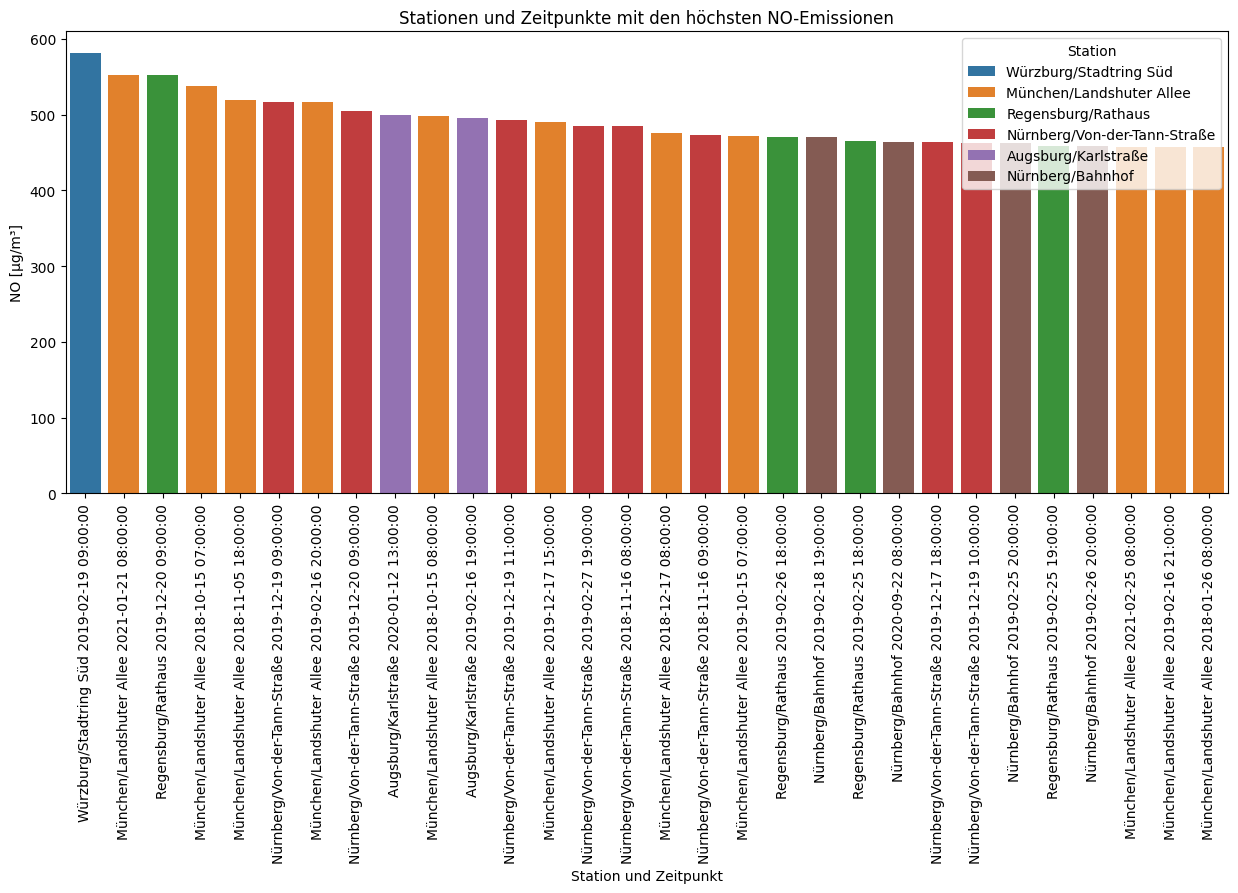

In [7]:
# change ascending to true to see the lowest values 
# change the head number to see more or less values
df_top_n_no = df[df["Element"] == "NO"].sort_values(by="Wert", ascending=False).head(30)

plt.figure(figsize=(15, 6))
sns.barplot(
    data=df_top_n_no,
    x=df_top_n_no['Station'] + " " + df_top_n_no['Zeitpunkt'].astype(str),
    y='Wert',
    hue='Station',
    dodge=False
)
plt.xticks(rotation=90, fontsize=10)
plt.xlabel("Station und Zeitpunkt")
plt.ylabel("NO [µg/m³]")
plt.title("Stationen und Zeitpunkte mit den höchsten NO-Emissionen")
plt.legend(title="Station")
plt.show()

**3.2 Bei welchen Stationen gibt es die höchsten O3-Emissionen?**

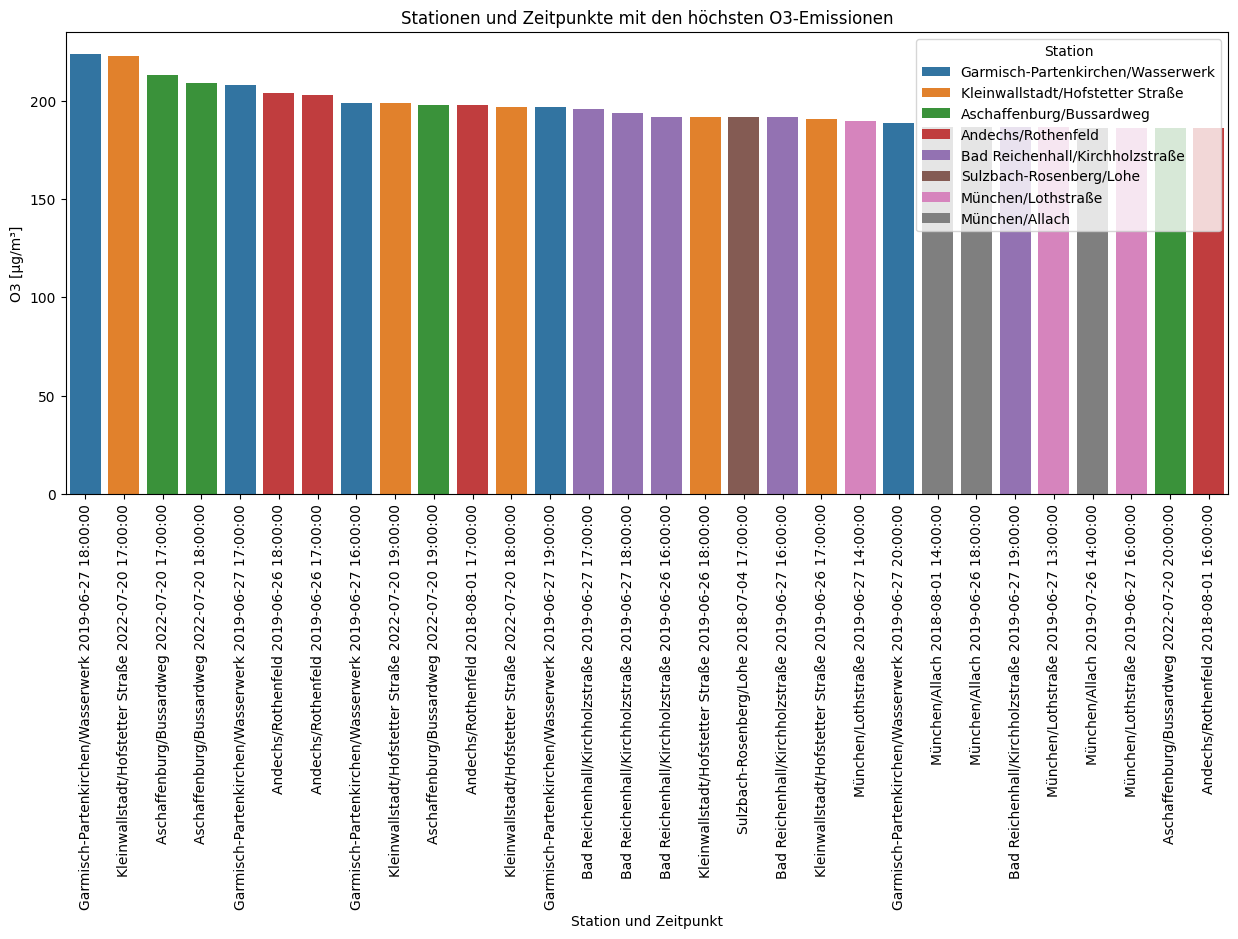

In [8]:
df_top_n_o3 = df[df["Element"] == "O3"].sort_values(by="Wert", ascending=False).head(30)

plt.figure(figsize=(15, 6))
sns.barplot(
    data=df_top_n_o3,
    x=df_top_n_o3['Station'] + " " + df_top_n_o3['Zeitpunkt'].astype(str),
    y='Wert',
    hue='Station',
    dodge=False
)
plt.xticks(rotation=90, fontsize=10)
plt.xlabel("Station und Zeitpunkt")
plt.ylabel("O3 [µg/m³]")
plt.title("Stationen und Zeitpunkte mit den höchsten O3-Emissionen")
plt.legend(title="Station", loc="upper right")
plt.show()

**3.3 Wie sehen die Durchschnittswerte über die Jahre in den Städten mit den höchsten Emissionen?**

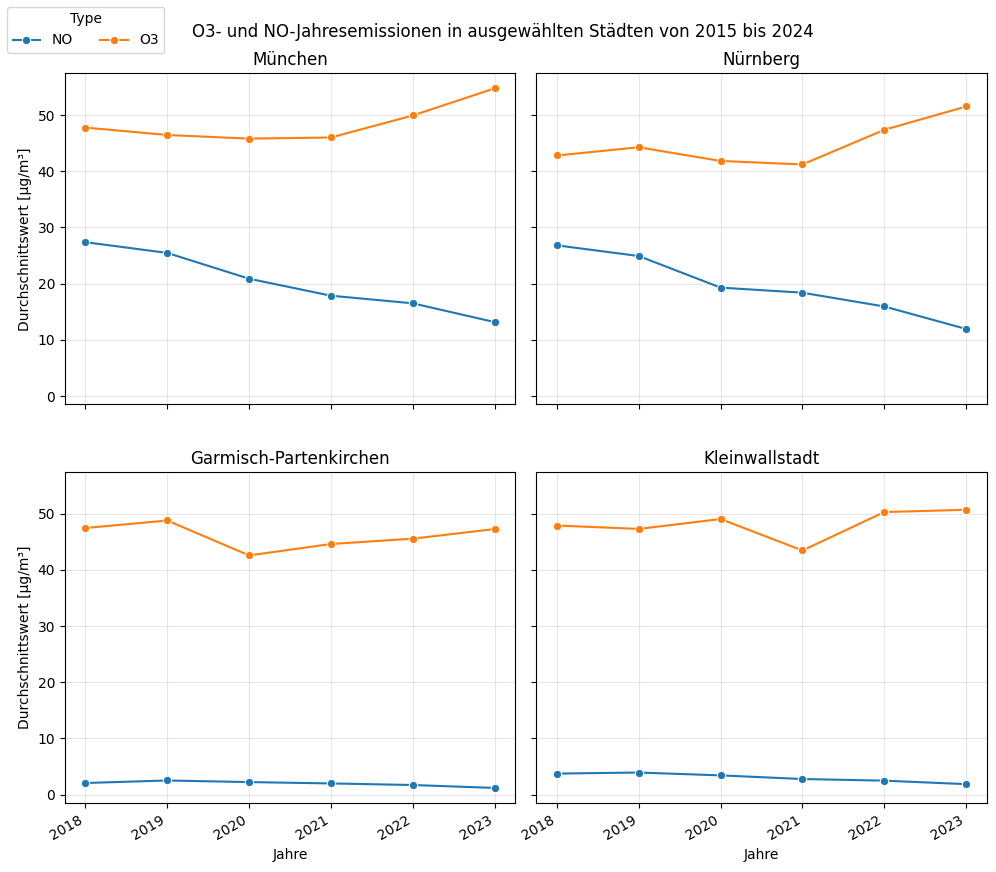

In [9]:
# choose four cities to compare
cities = ["München", "Nürnberg", "Garmisch-Partenkirchen", "Kleinwallstadt"]

# add a year column for easier grouping
df["year"] = df["Zeitpunkt"].dt.year.astype(int)

# Filter and group for stations
city1_grouped = (
    df[df["Station"].str.startswith(cities[0])]
    .groupby(["year", "Element"])["Wert"]
    .mean()
    .reset_index()
    .rename(columns={"Wert": "mean"})
)

city2_grouped = (
    df[df["Station"].str.startswith(cities[1])]
    .groupby(["year", "Element"])["Wert"]
    .mean()
    .reset_index()
    .rename(columns={"Wert": "mean"})
)

city3_grouped = (
    df[df["Station"].str.startswith(cities[2])]
    .groupby(["year", "Element"])["Wert"]
    .mean()
    .reset_index()
    .rename(columns={"Wert": "mean"})
)

city4_grouped = (
    df[df["Station"].str.startswith(cities[3])]
    .groupby(["year", "Element"])["Wert"]
    .mean()
    .reset_index()
    .rename(columns={"Wert": "mean"})
)

# create a dummy temp plot to get the legend
tmp = sns.lineplot(data=city1_grouped, x="year", y="mean", hue="Element", marker="o")
handles, labels = tmp.get_legend_handles_labels()
plt.close()


# use subplots to visualize the different stations
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)

sns.lineplot(
    data=city1_grouped, 
    x="year", y="mean", hue="Element", marker="o", 
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_title(cities[0])
axes[0, 0].set_xlabel("Jahre")
axes[0, 0].set_ylabel("Durchschnittswert [µg/m³]")
axes[0, 0].grid(True, alpha=0.3)

sns.lineplot(
    data=city2_grouped, 
    x="year", y="mean", hue="Element", marker="o", 
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_title(cities[1])
axes[0, 1].set_xlabel("Jahre")
axes[0, 1].set_ylabel("")
axes[0, 1].grid(True, alpha=0.3)

sns.lineplot(
    data=city3_grouped, 
    x="year", y="mean", hue="Element", marker="o", 
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title(cities[2])
axes[1, 0].set_xlabel("Jahre")
axes[1, 0].set_ylabel("Durchschnittswert [µg/m³]")
axes[1, 0].grid(True, alpha=0.3)

sns.lineplot(
    data=city4_grouped, 
    x="year", y="mean", hue="Element", marker="o", 
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_title(cities[3])
axes[1, 1].set_xlabel("Jahre")
axes[1, 1].set_ylabel("")
axes[1, 1].grid(True, alpha=0.3)

fig.legend(handles, labels, title="Type", loc="upper left", ncol=2)
fig.suptitle("O3- und NO-Jahresemissionen in ausgewählten Städten von 2015 bis 2024")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.gcf().autofmt_xdate()  # rotate the xticks a bit
plt.show()

**3.4 Wie sieht ein Tagesverlauf in München aus?**

Wir erinnern uns, dass wir bei der Datenvorverarbeitung die Tabellen mit Weitformat gespeichert haben. Mit ihnen können wir relativ einfach Tagesverlaufe visualisieren und miteinander vergleichen.

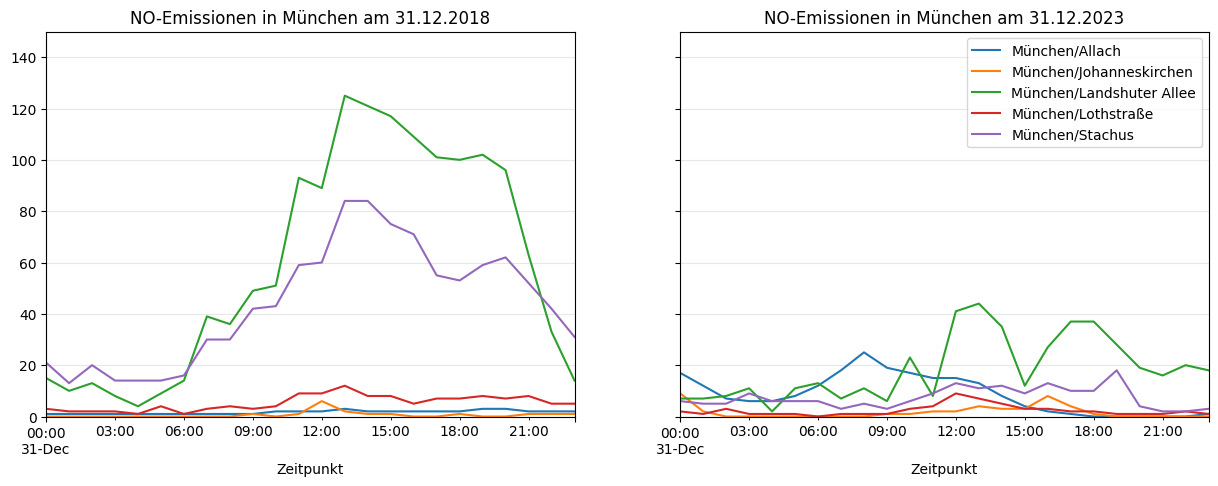

In [10]:
# pick a city and two days to compare
city_no = "München"
day1_no = "2018-12-31"
day2_no = "2023-12-31"

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_no_wide.loc[day1_no, df_no_wide.columns.str.startswith(city_no)].plot(ax=axes[0], legend=False, sharey=True, ylim=(0, 150))
df_no_wide.loc[day2_no, df_no_wide.columns.str.startswith(city_no)].plot(ax=axes[1], legend=False, sharey=True, ylim=(0, 150))

axes[0].set_title(f"NO-Emissionen in {city_no} am {datetime.strptime(day1_no, '%Y-%m-%d').strftime('%d.%m.%Y')}")
axes[1].set_title(f"NO-Emissionen in {city_no} am {datetime.strptime(day2_no, '%Y-%m-%d').strftime('%d.%m.%Y')}")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.legend(bbox_to_anchor=(1, 1), loc='upper right')
plt.show()

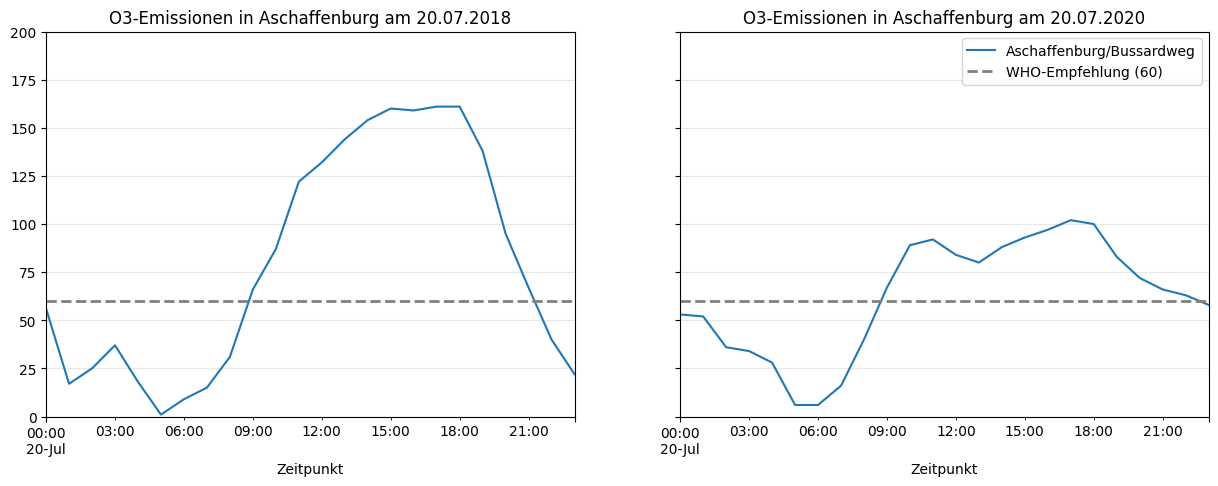

In [11]:
# pick a city and two days to compare
city_o3 = "Aschaffenburg"
day1_o3 = "2018-07-20"
day2_o3 = "2020-07-20"

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_o3_wide.loc[day1_o3, df_o3_wide.columns.str.startswith(city_o3)].plot(ax=axes[0], legend=False, sharey=True, ylim=(0, 200))
df_o3_wide.loc[day2_o3, df_o3_wide.columns.str.startswith(city_o3)].plot(ax=axes[1], legend=False, sharey=True, ylim=(0, 200))

# Add a constant horizontal line to indicate the WHO recommendation for AQG
for ax in axes:
    ax.axhline(y=60, color="grey", linestyle="--", linewidth=2, label="WHO-Empfehlung (60)")

axes[0].set_title(f"O3-Emissionen in {city_o3} am {datetime.strptime(day1_o3, '%Y-%m-%d').strftime('%d.%m.%Y')}")
axes[1].set_title(f"O3-Emissionen in {city_o3} am {datetime.strptime(day2_o3, '%Y-%m-%d').strftime('%d.%m.%Y')}")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.legend(bbox_to_anchor=(1, 1), loc='upper right')
plt.show()

**3.5 Wo befinden sich die Messstationen?**

Um die Lage der Messstationen zu visualisieren, benötigen wir die exakten Koordinaten jeder Station. Mithilfe von `Geopy` können wir den Ortsnamen über API schicken und bekommen die Koordinaten als Ergebins zurück.

In [12]:
# let's create a dataframe with the station names
df_sta = df[["Station"]].drop_duplicates(subset=["Station"])
df_sta["Station_parsed"] = df_sta["Station"].apply(lambda s: ", ".join(s.split("/")[::-1] + ["Bayern, Deutschland"]))

# use geocoders to get the coordinates of the stations
# use rate limiter to respect the API limits
geolocator = Nominatim(user_agent="dust_agents")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=2)

# get the coordinates of the stations - this might take a while
# you might get RateLimitedError, but it should still work
df_sta["Location"] = df_sta["Station_parsed"].apply(partial(geocode, language='de'))
df_sta["Point"] = df_sta["Location"].apply(lambda loc: tuple(loc.point) if loc else None)
df_sta[["Lat", "Lon", "Alt"]] = pd.DataFrame(df_sta["Point"].tolist(), index=df_sta.index)

In [13]:
df_sta.head()  # optionally display the first few rows

,Station,Station_parsed,Location,Point,Lat,Lon,Alt
0,Andechs/Rothenfeld,"Rothenfeld, Andechs, Bayern, Deutschland","(Rothenfeld, Andechs, Landkreis Starnberg, Bay...","(47.9707407, 11.2194752, 0.0)",47.970741,11.219475,0.0
1,Ansbach/Residenzstraße,"Residenzstraße, Ansbach, Bayern, Deutschland","(Residenzstraße, Kammerforst, Ansbach, Bayern,...","(49.3039012, 10.5750336, 0.0)",49.303901,10.575034,0.0
2,Aschaffenburg/Bussardweg,"Bussardweg, Aschaffenburg, Bayern, Deutschland","(Bussardweg, Strietwald, Aschaffenburg, Bayern...","(49.9922833, 9.1169701, 0.0)",49.992283,9.116970,0.0
3,Augsburg/Bourges-Platz,"Bourges-Platz, Augsburg, Bayern, Deutschland","(Bourges-Platz, Georgsviertel, Georgs- und Kre...","(48.3770752, 10.8895099, 0.0)",48.377075,10.889510,0.0
4,Augsburg/Karlstraße,"Karlstraße, Augsburg, Bayern, Deutschland","(Karlstraße, Innenstadt, St. Ulrich-Dom, Innen...","(48.3702166, 10.8965203, 0.0)",48.370217,10.896520,0.0


In [14]:
# merge the station data with the dust type
df_sta_merged = df.merge(df_sta, on="Station", how="right")

# aggregate the dust types by station, preserving lat, lon, alt columns
df_sta_merged_type = df_sta_merged.groupby(["Station"]).agg({
    "Element": lambda vals: ", ".join(sorted(set(vals))),
    "Lat": "first",
    "Lon": "first",
    "Alt": "first"}).reset_index()

# optionally print statistics and the df head
print(df_sta_merged_type.groupby("Element")["Station"].count())
# print(df_sta_merged_type.head())

# now let's create a map of the stations
# first define the center of the map
center = [df_sta_merged_type["Lat"].mean(), df_sta_merged_type["Lon"].mean()]
m = folium.Map(location=center, zoom_start=6, figsize=(10, 10))

for _, row in df_sta_merged_type.iterrows():

    # set the color of the marker based on the type
    if row["Element"] == "NO":
        color = "green"
    elif row["Element"] == "O3":
        color = "blue"
    else:
        color = "orange"

    # iterate over the rows and add the markers to the map
    if pd.notnull(row["Lat"]) and pd.notnull(row["Lon"]):
        folium.Marker(
            location=[row["Lat"], row["Lon"]],
            popup=f"{row['Element']}-Station: {row['Station']}",
            icon=folium.Icon(color=color)
        ).add_to(m)

m.save("dust_stations.html")
m  # display the map

Element
NO        19
NO, O3    31
O3         6
Name: Station, dtype: int64


**3.6 Können wir die Höhe der Emissionen pro Station auf der Karte darstellen?**

In [15]:
# aggregate the dust types by station, preserving lat, lon, alt columns
df_sta_merged_values = df_sta_merged.groupby(["Station", "Element"]).agg({
    "Wert": "mean",
    "Lat": "first",
    "Lon": "first",
    "Alt": "first"}).reset_index()

# here we only plot the NO stations
df_sta_merged_values_no = df_sta_merged_values[df_sta_merged_values["Element"] == "NO"]

# define the center of the map
center = [df_sta_merged_values_no["Lat"].mean(), df_sta_merged_values_no["Lon"].mean()]
m_no = folium.Map(location=center, zoom_start=6, figsize=(10, 10))

for _, row in df_sta_merged_values_no.iterrows():
    if pd.notnull(row["Lat"]) and pd.notnull(row["Lon"]):
        folium.CircleMarker(
            location=[row["Lat"], row["Lon"]],
            popup=f"{row['Element']}-Station: {row['Station']}. Durchschnittswert: {round(row['Wert'], 2)}",
            radius=row["Wert"],
            color="blue",
            fill=True,
            fill_color="blue",
        ).add_to(m_no)

m_no.save("dust_stations_circles_NO.html")  # save the map
m_no  # display the map

In [16]:
# aggregate the dust types by station, preserving lat, lon, alt columns
df_sta_merged_values = df_sta_merged.groupby(["Station", "Element"]).agg({
    "Wert": "mean",
    "Lat": "first",
    "Lon": "first",
    "Alt": "first"}).reset_index()

# here we only plot the NO stations
df_sta_merged_values_o3 = df_sta_merged_values[df_sta_merged_values["Element"] == "O3"]

# define the center of the map
center = [df_sta_merged_values_o3["Lat"].mean(), df_sta_merged_values_o3["Lon"].mean()]
m_o3 = folium.Map(location=center, zoom_start=6, figsize=(10, 10))

for _, row in df_sta_merged_values_o3.iterrows():
    if pd.notnull(row["Lat"]) and pd.notnull(row["Lon"]):
        folium.CircleMarker(
            location=[row["Lat"], row["Lon"]],
            popup=f"{row['Element']}-Station: {row['Station']}. Durchschnittswert: {round(row['Wert'], 2)}",
            radius=row["Wert"] / 5,  # divide by 5 to make the circles smaller
            color="blue",
            fill=True,
            fill_color="blue",
        ).add_to(m_o3)

m_o3.save("dust_stations_circles_O3.html")  # save the map
m_o3  # display the map

### 4. Aufgabe: COVID-19 und Luftqualität

Die COVID-19-Pandemie hat im Jahr 2020 zu weitreichenden Einschränkungen geführt, die sich auf die Luftqualität ausgewirkt haben könnten. 

**Ziel:**

1. Vergleiche die durchschnittlichen NO-Emissionen in München zwischen 2019 (vor der Pandemie) und 2020 (während der Pandemie)
2. Visualisiere die monatlichen Durchschnittswerte für beide Jahre in einem Diagramm
3. Identifiziere den Monat mit dem größten Unterschied zwischen 2019 und 2020

**Deine Aufgabe:**

Trage deine Antwort in die beiden Lücken in der Zelle unten ein.

In [17]:
# 1. Daten für München filtern und nur NO-Emissionen
## Trage deine Antwort ein
df_munich_no = df[__Deine Lösung hier__]

# 2. Spalten für Jahr und Monat hinzufügen
df_munich_no["year"] = df_munich_no["Zeitpunkt"].dt.year
df_munich_no["month"] = df_munich_no["Zeitpunkt"].dt.month

# 3. Daten für 2019 und 2020 filtern
df_munich_no_2019_2020 = df_munich_no[df_munich_no["year"].isin([2019, 2020])]

# 4. Monatliche Durchschnittswerte berechnen
## Trage deine Antwort ein
monthly_avg = df_munich_no_2019_2020.groupby(__Deine Lösung hier__)["Wert"].mean().reset_index().rename(columns={"Wert": "mean"})

# 5. Visualisierung
plt.figure(figsize=(10, 5))

for year in [2019, 2020]:
    data = monthly_avg[monthly_avg["year"] == year]
    plt.plot(
        data["month"], data["mean"], 
        label=str(year), marker="o", linewidth=2, markersize=8
    )

plt.xlabel("Monat")
plt.ylabel("Durchschnittswert NO [µg/m³]")
plt.title("Monatliche NO-Emissionen in München: Vergleich 2019 vs 2020")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
     "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
)
plt.legend(title="Jahr")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1606387869.py, line 3)

/var/folders/mr/9ht___f577vdc555j2_grnyw0000gn/T/ipykernel_10316/252882480.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_munich_no["year"] = df_munich_no["Zeitpunkt"].dt.year
/var/folders/mr/9ht___f577vdc555j2_grnyw0000gn/T/ipykernel_10316/252882480.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_munich_no["month"] = df_munich_no["Zeitpunkt"].dt.month


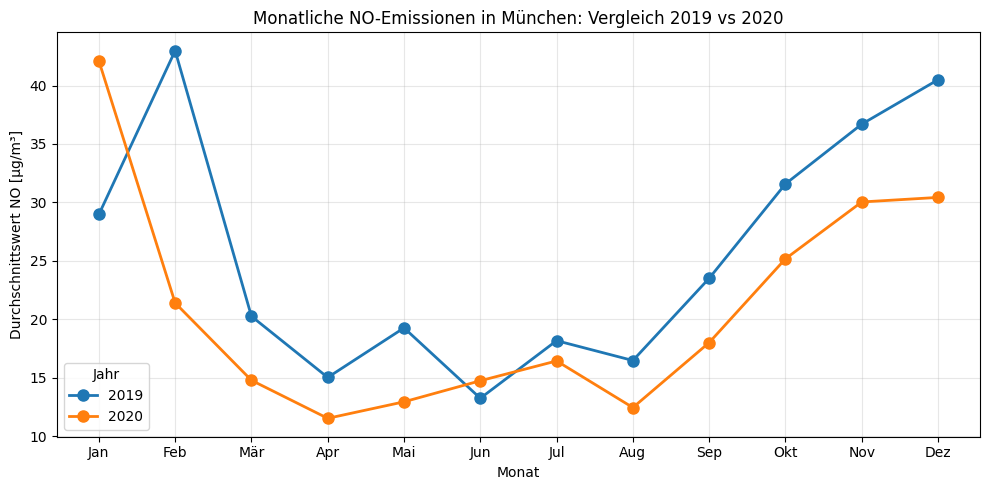

In [ ]:
# Lösung: Vergleich der NO-Emissionen in München zwischen 2019 und 2020

# 1. Daten für München filtern und nur NO-Emissionen
df_munich_no = df[(df["Station"].str.startswith("München")) & (df["Element"] == "NO")]

# 2. Spalten für Jahr und Monat hinzufügen
df_munich_no["year"] = df_munich_no["Zeitpunkt"].dt.year
df_munich_no["month"] = df_munich_no["Zeitpunkt"].dt.month

# 3. Daten für 2019 und 2020 filtern
df_munich_no_2019_2020 = df_munich_no[df_munich_no["year"].isin([2019, 2020])]

# 4. Monatliche Durchschnittswerte berechnen
monthly_avg = df_munich_no_2019_2020.groupby(["year", "month"])["Wert"].mean().reset_index().rename(columns={"Wert": "mean"})

# 5. Visualisierung
plt.figure(figsize=(10, 5))

for year in [2019, 2020]:
    data = monthly_avg[monthly_avg["year"] == year]
    plt.plot(
        data["month"], data["mean"], 
        label=str(year), marker="o", linewidth=2, markersize=8
    )

plt.xlabel("Monat")
plt.ylabel("Durchschnittswert NO [µg/m³]")
plt.title("Monatliche NO-Emissionen in München: Vergleich 2019 vs 2020")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
     "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
)
plt.legend(title="Jahr")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Zusammenfassung

In dieser Data Story haben wir die Emissionswerte von Stickstoffmonoxid (NO) und Ozon (O3) in Bayern für den Zeitraum 2015 bis 2024 untersucht und visualisiert. Unsere Analyse zeigt unter anderem:

- Die höchsten Emissionswerte in diesem Zeitraum konzentrieren sich bei einigen Messstationen (3.1/3.2)
- Auffällig hohe Ozonwerte treten in manchen kleineren Orten auf (3.2)
- Die NO-Emissionen zeigen eine absteigende Tendenz über die Jahre (3.3)
- Die räumliche Dichte und Überschneidungen der Messstationen wurden visualisiert (3.4)
- Die Höhe der Emissionen pro Station wurde graphisch dargestellt (3.5)

**Nächste Schritte und weitere Analyseideen**

Um noch tiefere Einblicke zu gewinnen, bieten sich folgende weiterführende Analysen an:

- Einbeziehung zusäzulicher Emissionswerten wie Feinstaub ([⁠PM2,5](https://open.bydata.de/datasets/lueb-messwerte-feinstaub-pm25?locale=de)⁠⁠), Stickstoffdioxid ([NO2](https://open.bydata.de/datasets/lueb-messwerte-no2?locale=de)) und Schwefeldioxid ([SO2](https://open.bydata.de/datasets/lueb-messwerte-so2?locale=de))
- Erweiterung der Analyse auf einen längeren Zeitraum, bspw. mit historischen Daten ab 1980 (verfügbar auf open bydata)
- Nähere Untersuchungen mit spezifischen Datensätzen aus [Augsburg](https://open.bydata.de/datasets/http-informationsportal-augsburg-de-opendataaugsburg-dataset-de-by-augsburg-geografie_klima_und_umwelt_-_immissionen_-_feinstaub-dataset?locale=de) und [Nürnberg](https://open.bydata.de/datasets?locale=de&query=Feinstaub+Nürnberg&page=1)
- Verknüpfung weiterer Datenquellen wie z.B. Wetter- und Verkehrsdaten, um komplexere Zusammenhänge und Einflussfaktoren zu erforschen